In [1]:
# ✅ 匯入核心模組
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset, ConcatDataset
import numpy as np
import os
import zipfile
from PIL import Image
from tqdm.notebook import tqdm  # 用於訓練進度條

# ✅ 運算裝置設定
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {DEVICE}")

# ✅ 隨機種子（確保結果可重現）
torch.manual_seed(42)
np.random.seed(42)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(42)

# ✅ PACS 基本資訊
PACS_DOMAINS = ['art_painting', 'cartoon', 'photo', 'sketch']
PACS_CATEGORIES = ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']

# ✅ 實驗超參數
MODEL_CHOICE = 'resnet18'
PRETRAINED = True
NUM_EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 3e-5

# ✅ 實驗設定摘要
print(f"🔧 Model: {MODEL_CHOICE}, Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")

🖥️ Using device: cuda
🔧 Model: resnet18, Epochs: 10, Batch: 32, LR: 3e-05


In [2]:
# ✅ 匯入必要模組
import os
import zipfile
import shutil
from google.colab import drive

# ✅ 掛載 Google Drive
drive.mount('/content/drive', force_remount=True)

# ✅ 創建 Google Drive 資料夾
drive_root = "/content/drive/MyDrive/domainbed_project"
os.makedirs(drive_root, exist_ok=True)

# ✅ 上傳 kaggle.json（第一次用這個帳號）
# 👉 請點左側「📁檔案」→ 右鍵上傳 kaggle.json 到 /content
kaggle_json_path = "/content/kaggle.json"
kaggle_config_dir = "/root/.kaggle"
os.makedirs(kaggle_config_dir, exist_ok=True)
shutil.copy(kaggle_json_path, os.path.join(kaggle_config_dir, "kaggle.json"))
os.chmod(os.path.join(kaggle_config_dir, "kaggle.json"), 0o600)
print("✅ kaggle.json 已成功設置")

# ✅ 安裝 kaggle CLI（如尚未安裝）
!pip install -q kaggle

# ✅ 從 Kaggle 下載 PACS 資料集（如尚未存在）
zip_path_drive = os.path.join(drive_root, "pacs-dataset.zip")
if not os.path.exists(zip_path_drive):
    print("⬇️ 正在從 Kaggle 下載 PACS 資料集...")
    !kaggle datasets download -d ma3ple/pacs-dataset -p "{drive_root}"
else:
    print("✅ 已存在 pacs-dataset.zip，跳過下載")

# ✅ 解壓縮 zip 到本地 /content/kfold
local_zip_path = "/content/pacs-dataset.zip"
shutil.copy(zip_path_drive, local_zip_path)

with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")
print("✅ 解壓完成，原始資料夾名稱為 'kfold'")

# ✅ 重新命名資料夾為 'PACS'
original_folder = "/content/kfold"
final_folder = "/content/PACS"
if os.path.exists(final_folder):
    shutil.rmtree(final_folder)
if os.path.exists(original_folder):
    os.rename(original_folder, final_folder)
    print("✅ 'kfold' 已重新命名為 'PACS'")
else:
    print("❌ 解壓後找不到 'kfold'，請檢查 zip 壓縮內容")

# ✅ 設定資料根路徑
BASE_PACS_PATH = final_folder
print(f"📂 Dataset base path is configured as: '{BASE_PACS_PATH}'")

Mounted at /content/drive
✅ kaggle.json 已成功設置
✅ 已存在 pacs-dataset.zip，跳過下載
✅ 解壓完成，原始資料夾名稱為 'kfold'
✅ 'kfold' 已重新命名為 'PACS'
📂 Dataset base path is configured as: '/content/PACS'


In [3]:
# 📦 Cell 4: 模型構建與驗證函數定義

import torch.nn as nn
from torchvision import models

# ✅ 構建 ResNet 模型
def get_model(num_classes=len(PACS_CATEGORIES), pretrained=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

# ✅ 測試模型建立
try:
    test_model = get_model(num_classes=len(PACS_CATEGORIES))
    print("✅ Model created successfully.")
except Exception as e:
    print(f"❌ Error creating model: {e}")

# ✅ 基本驗證函數（非 TTA）
def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    epoch_loss = running_loss / total if total > 0 else 0.0
    epoch_acc = correct / total if total > 0 else 0.0
    return epoch_loss, epoch_acc


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 87.6MB/s]


✅ Model created successfully.


In [4]:
# ✅ 圖像標準化轉換（適用於驗證與測試）
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [5]:
# ✅ 創建 baseline 模型與結果儲存目錄
baseline_dir = "/content/drive/MyDrive/xAi_DG_TTA/lodo_baseline_models"
os.makedirs(baseline_dir, exist_ok=True)
print(f"📁 Baseline models and results will be saved to: {baseline_dir}")

📁 Baseline models and results will be saved to: /content/drive/MyDrive/xAi_DG_TTA/lodo_baseline_models


In [6]:
from PIL import Image
from torch.utils.data import Dataset
import os

class PACS_Dataset(Dataset):
    def __init__(self, base_path, domain, categories, transform=None):
        self.transform = transform
        self.samples = []
        self.labels = []
        self.label_map = {label: idx for idx, label in enumerate(categories)}

        domain_path = os.path.join(base_path, domain)
        for label in os.listdir(domain_path):
            if label not in categories:
                continue
            label_dir = os.path.join(domain_path, label)
            for img_file in os.listdir(label_dir):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append(os.path.join(label_dir, img_file))
                    self.labels.append(self.label_map[label])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image = Image.open(self.samples[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label


In [7]:
import torch
import numpy as np
import json
from torch.utils.data import DataLoader

# ✅ 設定
BEST_MODEL_PATH = "/content/drive/MyDrive/xAi_DG_TTA/lodo_baseline_models/best_generalized_model.pth"
BASE_PACS_PATH = "/content/PACS"
SAVE_PATH = "/content/drive/MyDrive/xAi_DG_TTA/lodo_baseline_models/best_generalized_eval.json"

# ✅ 載入模型
model = get_model(len(PACS_CATEGORIES), PRETRAINED).to(DEVICE)
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

# ✅ 執行測試
domain_accs = {}
for domain in PACS_DOMAINS:
    val_dataset = PACS_Dataset(BASE_PACS_PATH, domain, PACS_CATEGORIES, transform=val_test_transform)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    _, val_acc = eval_one_epoch(model, val_loader, torch.nn.CrossEntropyLoss(), DEVICE)
    domain_accs[domain] = val_acc
    print(f"✔️ Accuracy on {domain}: {val_acc:.3f}")

# ✅ 計算平均
avg_acc = np.mean(list(domain_accs.values()))
print(f"\n🏁 Generalization Accuracy of Best Baseline Model: {avg_acc:.3f}")

# ✅ 儲存結果
with open(SAVE_PATH, "w") as f:
    json.dump({
        "model_path": BEST_MODEL_PATH,
        "per_domain_acc": domain_accs,
        "avg_acc": avg_acc
    }, f, indent=4)

print(f"\n✅ 測試結果已儲存至: {SAVE_PATH}")


✔️ Accuracy on art_painting: 1.000
✔️ Accuracy on cartoon: 1.000
✔️ Accuracy on photo: 0.954
✔️ Accuracy on sketch: 1.000

🏁 Generalization Accuracy of Best Baseline Model: 0.989

✅ 測試結果已儲存至: /content/drive/MyDrive/xAi_DG_TTA/lodo_baseline_models/best_generalized_eval.json


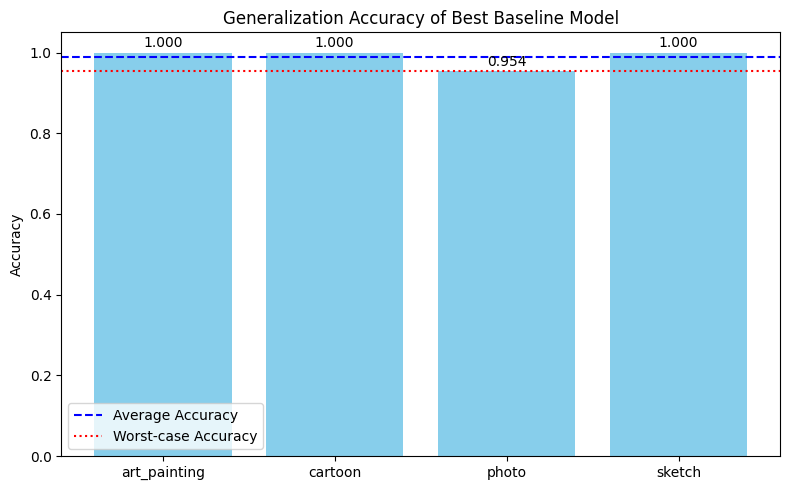

In [8]:
# ✅ 繪製柱狀圖（模型在四個 domain 上的泛化表現）
import matplotlib.pyplot as plt

# 使用剛剛測試完的結果繪圖（不需重新載入 JSON）
worst_acc = min(domain_accs.values())

plt.figure(figsize=(8, 5))
domains = list(domain_accs.keys())
accs = list(domain_accs.values())

bars = plt.bar(domains, accs, color='skyblue')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom')

plt.axhline(avg_acc, color='blue', linestyle='--', label='Average Accuracy')
plt.axhline(worst_acc, color='red', linestyle=':', label='Worst-case Accuracy')

plt.title("Generalization Accuracy of Best Baseline Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()